# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp

g0 = 9.81
h = 4000
t = np.sqrt(2 * h / g0)
print(f"Fall time: {t:.6f} s")

Fall time: 28.556862 s


In [2]:
def dydt_gravity(t, s):
    # s[0] = pos (y)
    # s[1] = vel (v)
    assert len(s) == 2
    # Drag opposes motion: alpha * |velocity|^gamma
    drag_force = alpha * np.abs(s[1])**gamma
    dvdt = -g0 + drag_force
    # Return [dy/dt, dv/dt]
    # dy/dt is just the velocity: s[1]
    # dv/dt is acceleration: -g + drag_force
    return [s[1], dvdt]

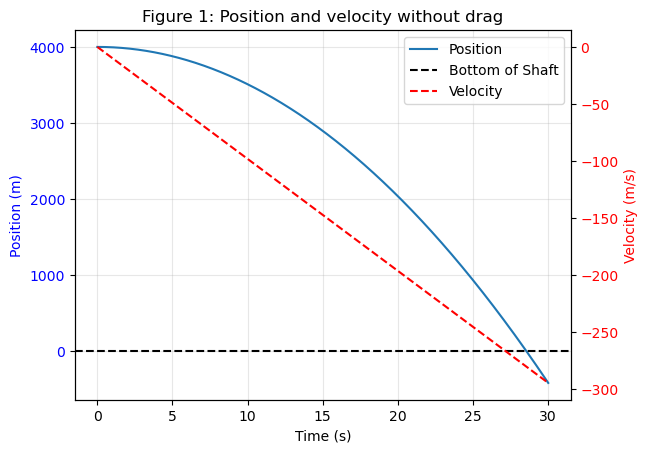

In [3]:
alpha = 0  # No drag for this section
gamma = 2
t_span = (0, 40)
y0 = [h, 0]
t_span = [0,30]

sol = solve_ivp(dydt_gravity, [0, 30], [4000, 0], dense_output=True)


tt = np.linspace(0,30, 1000) 
yy, vv = sol.sol(tt)


# plots 
fig, ax1 = plt.subplots() 

# position plot 

ax1.plot(tt, yy, label="Position") # plot of position
ax1.axhline(0, color='black', linestyle='--', label='Bottom of Shaft') # Horizontal dashed line
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Position (m)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# second (velocity) plot with twinx 
ax2 = ax1.twinx()  # twin x axis
ax2.plot(tt, vv, color="red", ls='--', label="Velocity") # plot of velocity
ax2.set_ylabel('Velocity (m/s)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title("Figure 1: Position and velocity without drag") # title
ax1.legend()

# Plot one combined legend on ax1

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right') # legend of both axies

plt.show()

In [4]:
def hit_ground(t, s):
    return s[0]

soln = solve_ivp(dydt_gravity, [0, 30], [4000, 0], events=hit_ground)

t_numeric = soln.t_events[0][0]

t_analytic = np.sqrt(2*h/g0)

print(f"Numerical time: {t_numeric:.6f} s")
print(f"Analytical time : {t_analytic:.6f} s")
print(f"Difference : {abs(t_numeric-t_analytic):.2e} s")

Numerical time: 28.556862 s
Analytical time : 28.556862 s
Difference : 2.49e-14 s


## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



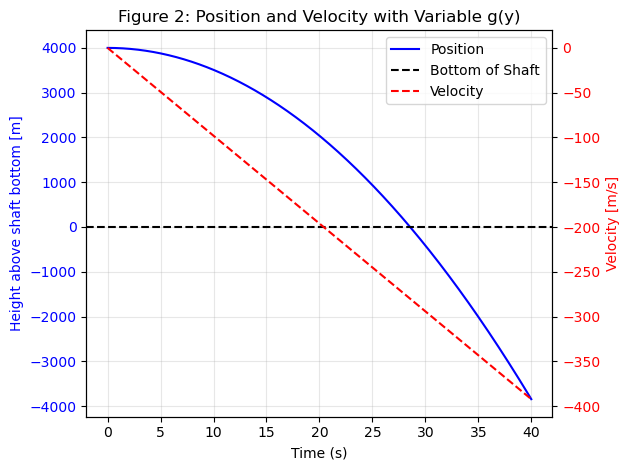

In [5]:
g0 = 9.81
R_earth = 6378.1e3  # Radius in meters
h_start = 4000      # 4km shaft

def g(y):
    r = (R_earth - h_start) + y  # radius from center of Earth
    return g0 * (r / R_earth)

def dydt_g_var(t, s):
    y, v = s
    dvdt = -g(y)        # no drag
    dydt = v
    return [dydt, dvdt]

t_end = 40

sol = solve_ivp(dydt_g_var, [0, t_end], [h_start, 0], dense_output=True)

tt = np.linspace(0, t_end, 1000)
yy, vv = sol.sol(tt)

# -- Figure 2 ----------------------------------------
fig, ax1 = plt.subplots()

# position graph
ax1.plot(tt, yy, color='blue', label='Position')
ax1.axhline(0, color='black', linestyle='--', label='Bottom of Shaft')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Height above shaft bottom [m]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# velocity graph 
ax2 = ax1.twinx()
ax2.plot(tt, vv, color='red', linestyle='--', label='Velocity')
ax2.set_ylabel('Velocity [m/s]', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Figure 2: Position and Velocity with Variable g(y)')
plt.tight_layout()
plt.show()

Because the gravitational acceleration decreases as the object moves deeper into the Earth, the object experiences less acceleration during the fall compared to the constant g case. As a result, the object gains speed more slowly and reaches a lower maximum velocity. Therefore, incorporating a height dependent gravitational acceleration increases the total fall time. The effect is relatively small for a shallow shaft (like 4 km) because the change in g over that distance is very small compared to the Earth’s radius.

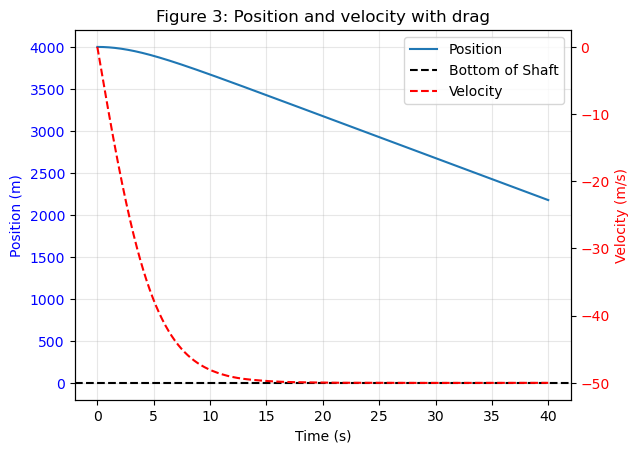

In [6]:
alpha = 9.81/ (50**2)  # drag for this section
gamma = 2

t_span = (0, 40)

h=4000
y0 = [h, 0]

sol = solve_ivp(dydt_gravity, t_span, y0, dense_output=True)


tt = np.linspace(0,40, 1000) 
yy, vv = sol.sol(tt)


# plots 
fig, ax1 = plt.subplots() 

# position plot 

ax1.plot(tt, yy, label="Position") # plot of position
ax1.axhline(0, color='black', linestyle='--', label='Bottom of Shaft') # Horizontal dashed line
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Position (m)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# second (velocity) plot with twinx 
ax2 = ax1.twinx()  # twin x axis
ax2.plot(tt, vv, color="red", ls='--', label="Velocity") # plot of velocity
ax2.set_ylabel('Velocity (m/s)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title("Figure 3: Position and velocity with drag") # title
ax1.legend()

# Plot one combined legend on ax1

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right') # legend of both axies

plt.show()

Including drag increases the fall time because the drag force opposes the motion of the falling object, reducing its acceleration and limiting its velocity. Instead of simply accelerating downward, the object approaches a terminal speed near 50 m/s. As a result, the object falls much more slowly and takes significantly longer to reach the bottom of the shaft compared to the no-drag case.

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




#### Calculations:

$$F_{c_x} = ma_x=2m\Omega v_y \implies a_x = 2\Omega v_y$$
$$F_{c_y} = ma_y=2m\Omega v_x \implies a_y = 2\Omega v_x$$

Now, we sum the forces to use $F=ma$, to get acceleration in the $x$ and $y$ directions. 

So, 
$$a_ = $$
$$a_x = \frac{\sum{F_x}}{m} = \frac{2m\Omega v_y - \alpha v^{\gamma -1}v_x}{m} = 2\Omega v_y - \frac{\alpha}{m} v^{\gamma -1}v_x$$
$$a_y = \frac{\sum{F_y}}{m} = \frac{mg - 2m\Omega v_x - \alpha v^{\gamma -1}v_y}{m} = g - 2\Omega v_x - \frac{\alpha}{m} v^{\gamma -1}v_y$$

Let the drag in the x and y directions be denoted as follows, 
$$drag_x = - \frac{\alpha}{m} v^{\gamma -1}v_x $$
$$drag_y= - \frac{\alpha}{m} v^{\gamma -1}v_y $$

Then, 
$$a_x = 2\Omega v_y + drag_x$$
$$a_y = g - 2\Omega v_x + drag_y$$

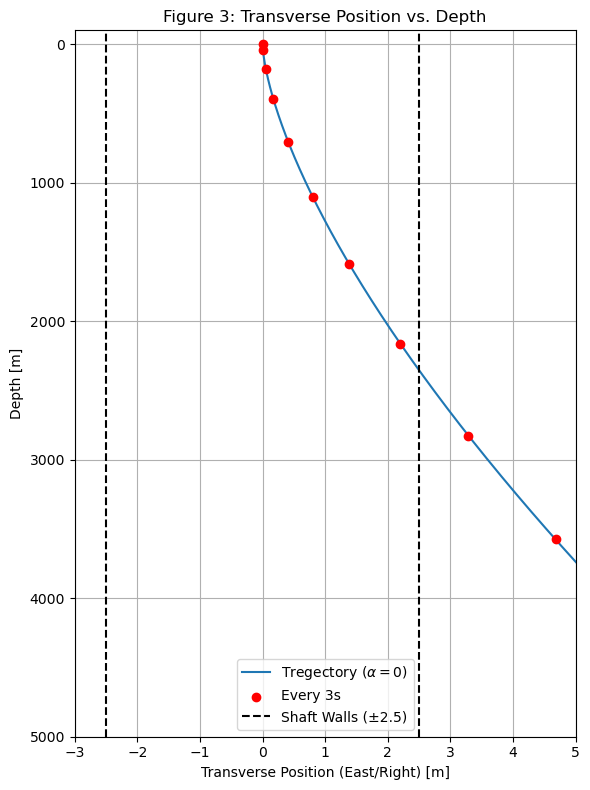

In [7]:
Omega = 7.272e-5  # rad/s
m = 1             # kg
def dydt_coriolis(t, s, alpha, gamma):
     x, y, vx, vy = s
     
     v_mag = np.sqrt(vx**2 + vy**2)
     
     # 1. Coriolis Acceleration + Drag Acceleration
     # ax = (F_coriolis_x - F_drag_x) / m
     
     ax = 2 * Omega * vy - (alpha * v_mag**(gamma-1) * vx / m)
     
     # ay = (F_gravity - F_coriolis_y - F_drag_y)
     
     ay = g0 - 2 * Omega * vx - (alpha * v_mag**(gamma-1) * vy / m)
     
     return [vx, vy, ax, ay]

#  Initial conditions: dropped from rest at top center 
# s = [x, y, vx, vy] = [0, 0, 0, 0]

s0 = [0.0, 0.0, 0.0, 0.0]

t_span = (0, 40)

# Solve with alpha=0 for Figure 3
soln = solve_ivp(dydt_coriolis, t_span, s0, args=(0.0, 2.0), dense_output=True)

tt = np.linspace(0, 40, 1000)
xx, yy, vx, vy = soln.sol(tt)

# plot figure 3 

fig3, ax = plt.subplots(figsize=(6,8))

ax.plot(xx,yy, label=r"Tregectory ($\alpha=0$)")

# Plot dots every 3 seconds

t_dots = np.arange(0, 40, 3) # Create time markers

# Evaluate state at exactly the time points
xx_dots, yy_dots, _, _ = soln.sol(t_dots) # _,_ denotes dummy variables

ax.scatter(xx_dots, yy_dots, color="red", label="Every 3s", zorder=5)

# Formatting Figure 3

ax.axvline(x = 2.5, color="black", linestyle="--", label="Shaft Walls (±2.5)")
ax.axvline(-2.5, color='black', ls='--')

ax.set_xlabel("Transverse Position (East/Right) [m]")
ax.set_ylabel("Depth [m]")
ax.set_title("Figure 3: Transverse Position vs. Depth")

ax.legend()
ax.grid(True)
ax.set_xlim(-3,5)
ax.set_ylim(-100,5000)
ax.invert_yaxis() # Invert so depth increases downward

plt.tight_layout()

plt.show()



The mass hits the wall before it reaches the bottom as shown in the above figure. If we check out `xx` array, we will find it exceeds 2.5m at a depth of approximately 2,300 meters, which is well before the 4,000 meter bottom.

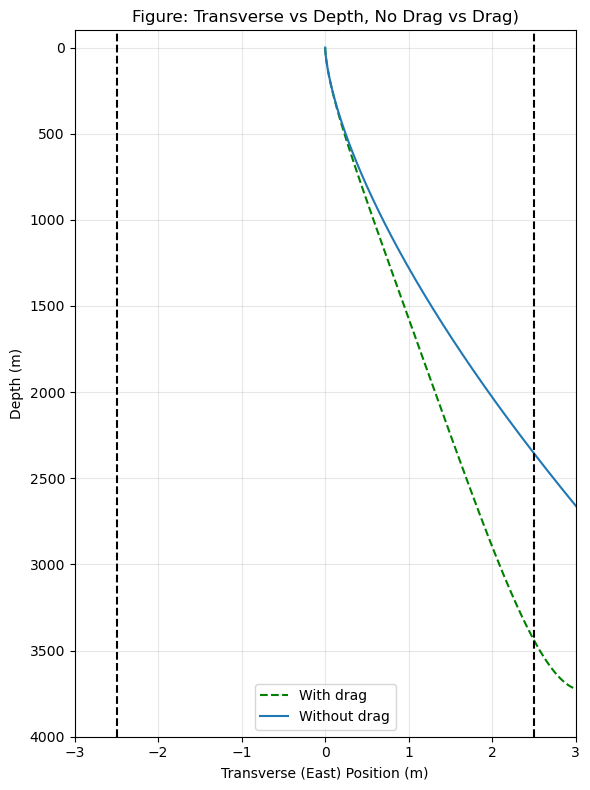

In [8]:
# Now, turning drag on (drag case)

alpha = 9.81 / (50**2)

def dydt_coriolis(t, s, alpha, gamma):
     x, y, vx, vy = s
     
     v_mag = np.sqrt(vx**2 + vy**2)
     
     # 1. Coriolis Acceleration + Drag Acceleration
     # ax = (F_coriolis_x - F_drag_x) / m
     
     ax = 2 * Omega * vy - (alpha * v_mag**(gamma-1) * vx / m)
     
     # ay = (F_gravity - F_coriolis_y - F_drag_y)
     
     ay = g0 - 2 * Omega * vx - (alpha * v_mag**(gamma-1) * vy / m)
     
     return [vx, vy, ax, ay]


t_span = (0,40)

s0 = [0.0,0.0,0.0,0.0]  # initial condition

soln_drag = solve_ivp(dydt_coriolis, t_span, s0,args=(alpha,2.0), dense_output=True) # solution

tt_d = np.linspace(0, 1000, 5000)

xx_d, yy_d, vx_d, vy_d = soln_drag.sol(tt_d)

fig, ax = plt.subplots(figsize=(6, 8)) 

ax.plot(xx_d, yy_d, 'g--',label = "With drag")
ax.plot(xx, yy,label = "Without drag")

ax.axvline(x=2.5,color="black", ls='--')
ax.axvline(x=-2.5,color="black", ls='--')
ax.set_ylim(-100, 4000)
ax.set_xlim(-3,3)
ax.grid(True, alpha=0.3)

ax.set_xlabel('Transverse (East) Position (m)')
ax.set_ylabel('Depth (m)')
ax.set_title('Figure: Transverse vs Depth, No Drag vs Drag)')
ax.invert_yaxis()
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


As shown above, the test mass hits the wall faster without drag. There is about a 1000m difference between with and without drag.

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





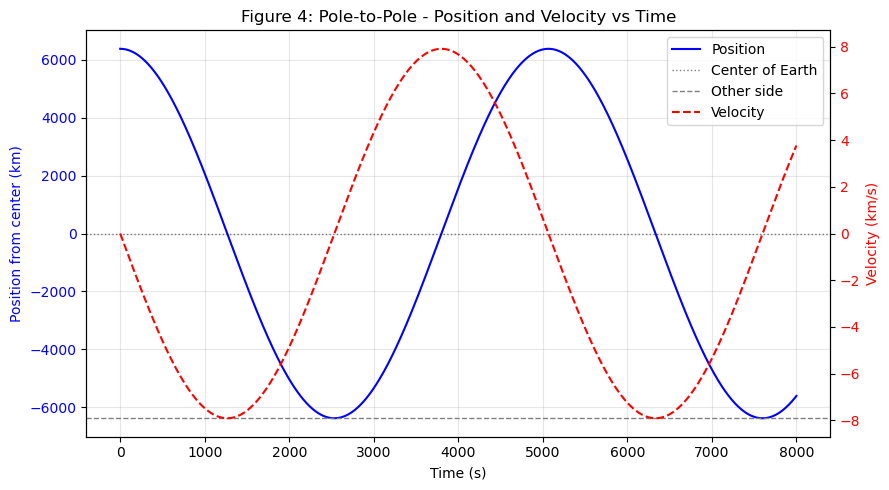

In [9]:
# Constants
G       = 6.6743e-11
M_earth = 5.972e24    # kg 
R_earth = 6378.1e3      # m 
g0      = 9.81

# For pole-to-pole tunnel with uniform density:
# g(r) = g0 * (r / R_earth), pointing back toward center
# y = displacement from center (positive = toward starting pole)
# So at t=0, y = R_earth, v_y = 0

def dydt_infty(t, s):
    y, v = s
    r = abs(y)                        # distance from center
    g = g0 * (r / R_earth)            # gravity magnitude
    a = -np.sign(y) * g               # always points toward center
    return [v, a]

s0  = [R_earth, 0.0] # initial condition, we are at the center and velocity is 0.0

t_max = 8000 # Enough for nearly 2 full cycles

sol = solve_ivp(dydt_infty, [0, t_max], s0, dense_output=True,
                max_step=10)

# Run for a few full oscillations
t_end = 8000
tt = np.linspace(0, t_end, 5000)
yy, vv = sol.sol(tt)

# -- Figure 4 ----------------------------
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(tt, yy/1000, color='blue', label='Position')

ax1.axhline(0,  color='black', ls=':', lw=1, alpha=0.5, label='Center of Earth')

ax1.axhline(-R_earth/1e3, color='gray', ls='--', lw=1, label='Other side')

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Position from center (km)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# --- velocity plot -----
ax2 = ax1.twinx()
ax2.plot(tt, vv/1000, color='red', ls='--', label='Velocity')
ax2.set_ylabel('Velocity (km/s)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- legend -----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Title
ax1.set_title('Figure 4: Pole-to-Pole - Position and Velocity vs Time')

plt.tight_layout()
plt.show()

In [10]:
# Find the index where y is closest to 0 (the center)
center = np.argmin(np.abs(yy))
time_center_min = tt[center] / 60
speed_center_kms = abs(vv[center]) / 1000

# Find the index where y is closest to -R_earth "the other side"
idx_other_side = np.argmin(np.abs(yy - (-R_earth)))
t_other_side = tt[idx_other_side] / 60

print(f"Time to Center: {time_center_min:.2f} minutes")
print(f"Speed at Center: {speed_center_kms:.2f} km/s")
print(f"Time to Other Side: {t_other_side:.2f} minutes")


Time to Center: 105.54 minutes
Speed at Center: 7.91 km/s
Time to Other Side: 42.22 minutes


In [11]:
v_orb = np.sqrt(G * M_earth / R_earth)
T_orb = 2 * np.pi * R_earth / v_orb
print(f"\nOrbital speed:   {v_orb/1e3:.3f} km/s")
print(f"Orbital period:  {T_orb:.1f} s  ({T_orb/60:.2f} min)")
print(f"Tunnel crossing (one way): {t_other_side:.1f} s  = T_orb / {T_orb/t_other_side:.2f}")



Orbital speed:   7.905 km/s
Orbital period:  5069.4 s  (84.49 min)
Tunnel crossing (one way): 42.2 s  = T_orb / 120.07


In [12]:
# Theoretical Calculations 
# v^2 / R = G * M / R^2  -->  v = sqrt(G * M / R)

v_orbital = np.sqrt(G * M_earth / R_earth)  # Orbital speed in m/s
T_orbital = (2 * np.pi * R_earth) / v_orbital  # Orbital period in seconds


# Find index where the object passes the center (y=0)
center = np.argmin(np.abs(yy))
t_center = tt[center]
v_center = abs(vv[center])

# Find index where the object first hits the other side (y = -R_earth)
other_side = np.argmin(np.abs(yy - (-R_earth)))
t_crossing = tt[other_side]

# --- 3. Print the Comparison Report ---
print("="*50)
print("PART 3: ORBITAL PERIOD COMPARISON ANALYSIS")
print("="*50)
print(f"Theoretical Orbital Speed:     {v_orbital / 1000:7.3f} km/s")
print(f"Simulated Max Speed at Center: {v_center / 1000:7.3f} km/s")
print("-"*50)
print(f"Theoretical Orbital Period:    {T_orbital / 60:7.2f} minutes")
print(f"Simulated Total Tunnel Cycle:  {(t_crossing * 2) / 60:7.2f} minutes")
print("-"*50)
print(f"Simulated Crossing-Time (N->S): {t_crossing / 60:6.2f} minutes")
print(f"Half of the Orbital Period:    {(T_orbital / 2) / 60:6.2f} minutes")
print("="*50)

PART 3: ORBITAL PERIOD COMPARISON ANALYSIS
Theoretical Orbital Speed:       7.905 km/s
Simulated Max Speed at Center:   7.910 km/s
--------------------------------------------------
Theoretical Orbital Period:      84.49 minutes
Simulated Total Tunnel Cycle:    84.44 minutes
--------------------------------------------------
Simulated Crossing-Time (N->S):  42.22 minutes
Half of the Orbital Period:     42.24 minutes


The data confirms that the crossing-time of a tunnel is exactly equal to half of the surface orbital period. Mathematically, falling through a constant-density Earth is the 1-dimensional projection of a 2-dimensional circular orbit.")


## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

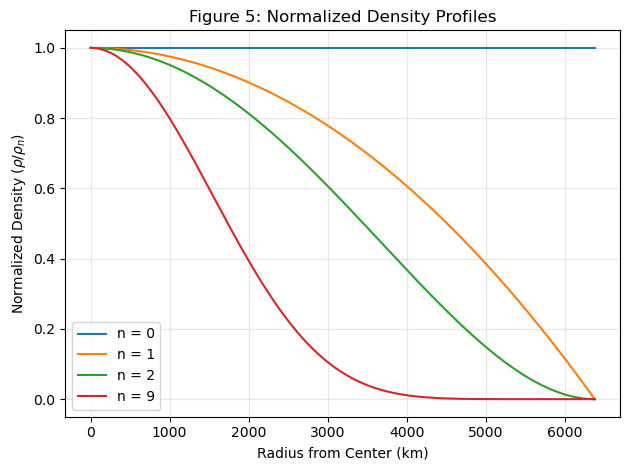

In [13]:
R_earth = 6378.1e3  # m
r_vals = np.linspace(0, R_earth, 1000)

fig5, ax5 = plt.subplots()
for n in [0, 1, 2, 9]:
    rho_norm = (1.0 - (r_vals / R_earth)**2)**n
    ax5.plot(r_vals / 1e3, rho_norm, label=f'n = {n}')

ax5.set_xlabel('Radius from Center (km)')
ax5.set_ylabel('Normalized Density ($\\rho / \\rho_n$)')
ax5.set_title('Figure 5: Normalized Density Profiles')
ax5.legend()
ax5.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Part 5, Section B (Forces)

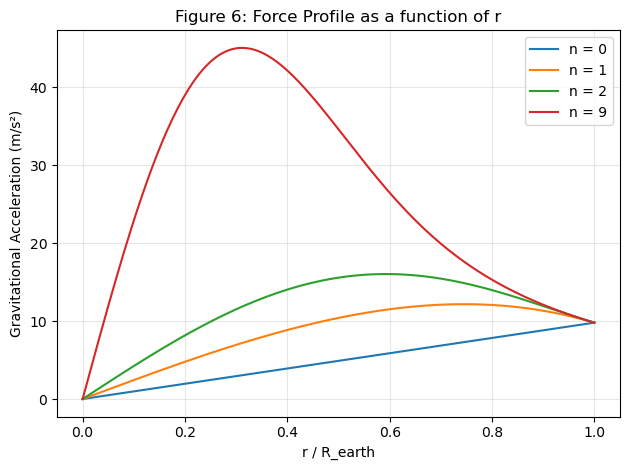

In [14]:
from scipy.integrate import quad
from scipy.interpolate import interp1d

# --- Constants ---
G       = 6.6743e-11
M_earth = 5.972e24
R_earth = 6378.1e3
g0      = 9.81
n_vals  = [0, 1, 2, 9]

#  Functions 
def rho_un(r, n):
    """
    Unnormalized density profile.
    """
    return (1.0 - (r / R_earth)**2)**n

def get_rho_n(n):
    """
    Computes rho_n normalization constant using quad.
    """
    integrand = lambda r: rho_un(r, n) * r**2
    integral, _ = quad(integrand, 0, R_earth)
    return M_earth / (4 * np.pi * integral)

def g_nonuniform(r, n, rho_n):
    """
    Gravity at radius r for density profile with exponent n using quad.
    """
    if r == 0:
        return 0.0
    integrand = lambda rp: rho_n * rho_un(rp, n) * rp**2
    mass_inside, _ = quad(integrand, 0, r)
    mass_inside *= 4 * np.pi
    return G * mass_inside / r**2

# --- Dictionary to store functions for solve_ivp ---
g_interpolator = {}

# Create a radius array for plotting
r_arr = np.linspace(0, R_earth, 200)

# plot figure 6 

fig6, ax6 = plt.subplots()

for n in n_vals:
    rho_n  = get_rho_n(n)
    
    # Calculate g for every radius point in the array using quad
    g_arr  = [g_nonuniform(r, n, rho_n) for r in r_arr]
    
    ax6.plot(r_arr / R_earth, g_arr, label=f'n = {n}') # plot 
     
    # Save an interp1d object so solve_ivp works
    g_interpolator[n] = interp1d(r_arr, g_arr, kind='cubic', bounds_error=False, fill_value="extrapolate")

ax6.set_xlabel('r / R_earth')
ax6.set_ylabel('Gravitational Acceleration (m/s²)')
ax6.set_title('Figure 6: Force Profile as a function of r')
ax6.legend()
ax6.grid(True, alpha=0.3)
plt.tight_layout()



### Part 5, Section C (Equations of Motion)


Part 4 results:
   n    t_center (min)   v_center (km/s)
   0             21.12             7.905
   1             54.83            10.458
   2             17.25            12.183
   9             78.65            18.371


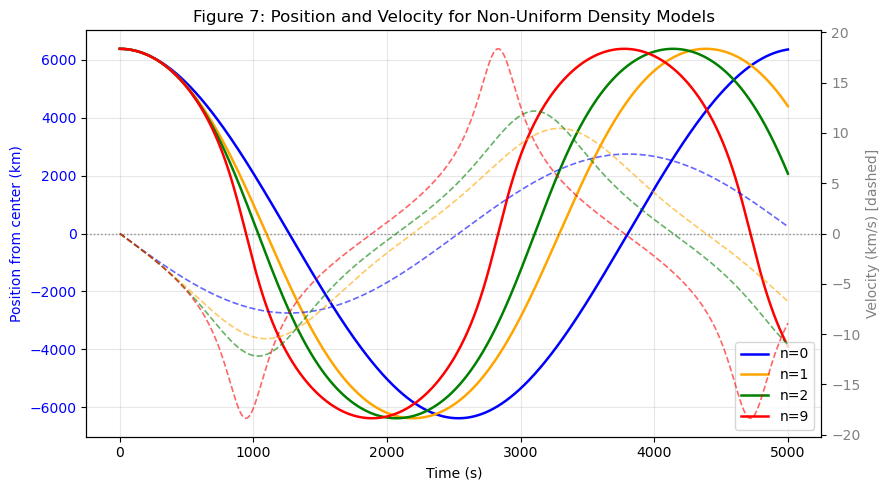

In [15]:
# dictionary is set up before the loop runs 
g_interpolators = {}

def dydt_nonuniform(t, s, n):
    y, v = s
    r = abs(y)
    g_val = g_interpolators[n](r)
    a = -np.sign(y) * g_val
    return [v, a]

def make_g_interp(n):
    rho_n = get_rho_n(n)
    g_arr = [g_nonuniform(r, n, rho_n) for r in r_arr]
    # Returns the cubic spline lookup object
    return interp1d(r_arr, g_arr, kind='cubic', fill_value="extrapolate")


# Figure 7: position and velocity for each n 
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

colors = ['blue', 'orange', 'green', 'red']
t_end  = 5000
tt     = np.linspace(0, t_end, 5000)

print("\nPart 4 results:")
print(f"{'n':>4}  {'t_center (min)':>16}  {'v_center (km/s)':>16}")

for n, color in zip(n_vals, colors):
    # must populate  global g_interpolators[n] used by dydt_nonuniform
    g_interpolators[n] = make_g_interp(n)

    sol_n = solve_ivp(dydt_nonuniform, [0, t_end], s0,
                      args=(n,), dense_output=True, max_step=10)
    
    yy_n, vv_n = sol_n.sol(tt)

    # have center 
    center_idx = np.argmin(np.abs(yy_n))
    
    # Extract seconds and  m/s first
    t_center_seconds = tt[center_idx]
    v_center_ms      = abs(vv_n[center_idx])
    
    # Perform unit conversions  
    t_center_min = t_center_seconds / 60
    v_center_kms = v_center_ms / 1000
    
    # print table 
    print(f"{n:>4}  {t_center_min:>16.2f}  {v_center_kms:>16.3f}")

    # Plot lines on their respective axes
    ax1.plot(tt, yy_n / 1e3, color=color, lw=1.8, label=f'n={n}')
    ax2.plot(tt, vv_n / 1e3, color=color, lw=1.2, ls='--', alpha=0.6)

ax1.axhline(0, color='black', ls=':', lw=1, alpha=0.4)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Position from center (km)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.set_ylabel('Velocity (km/s) [dashed]', color='gray')
ax2.tick_params(axis='y', labelcolor='gray') # Styled axis text to match line

ax1.set_title('Figure 7: Position and Velocity for Non-Uniform Density Models')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [16]:
# ---  Constants ---
G       = 6.6743e-11
M_earth = 5.972e24      # kg
R_earth = 6378.1e3     # m

M_moon  = 7.3477e22     # kg
R_moon  = 1737.4e3      # m

# --- Calculate Volumetric Densities ---
rho_earth = M_earth / ((4/3) * np.pi * R_earth**3)
rho_moon  = M_moon / ((4/3) * np.pi * R_moon**3)

# Surface gravity of the moon
g_moon = G * M_moon / (R_moon**2)

# ---  Define Lunar Gravity System ---
def dydt_moon(t, s):
    y, v = s
    a = -g_moon * (y / R_moon)
    return [v, a]

# solution for moon 
s0_moon = [R_moon, 0.0]
soln_moon = solve_ivp(dydt_moon, [0, 5000], s0_moon, dense_output=True, max_step=10)

tt_m = np.linspace(0, 4000, 4000)
yy_m, _ = soln_moon.sol(tt_m)

# Extract center crossing index using array method

center_moon = np.argmin(np.abs(yy_m))
t_center_moon = tt_m[center_moon] / 60

# Print Summary

print("="*60)
print("PART 6: LUNAR GRAVITY TUNNEL REPORT")
print("="*60)
print(f"Homogeneous Earth Density: {rho_earth:7.2f} kg/m³")
print(f"Homogeneous Moon Density:  {rho_moon:7.2f} kg/m³")
print(f"Density Ratio (Moon/Earth): {rho_moon / rho_earth:7.4f}")
print("-"*60)
print(f"Simulated Time to Moon Center:   {t_center_moon:6.2f} minutes")
print(f"Analytical Prediction via Density: {21.12 * np.sqrt(rho_earth/rho_moon):6.2f} minutes")
print("="*60)


PART 6: LUNAR GRAVITY TUNNEL REPORT
Homogeneous Earth Density: 5494.87 kg/m³
Homogeneous Moon Density:  3344.75 kg/m³
Density Ratio (Moon/Earth):  0.6087
------------------------------------------------------------
Simulated Time to Moon Center:    27.07 minutes
Analytical Prediction via Density:  27.07 minutes


## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

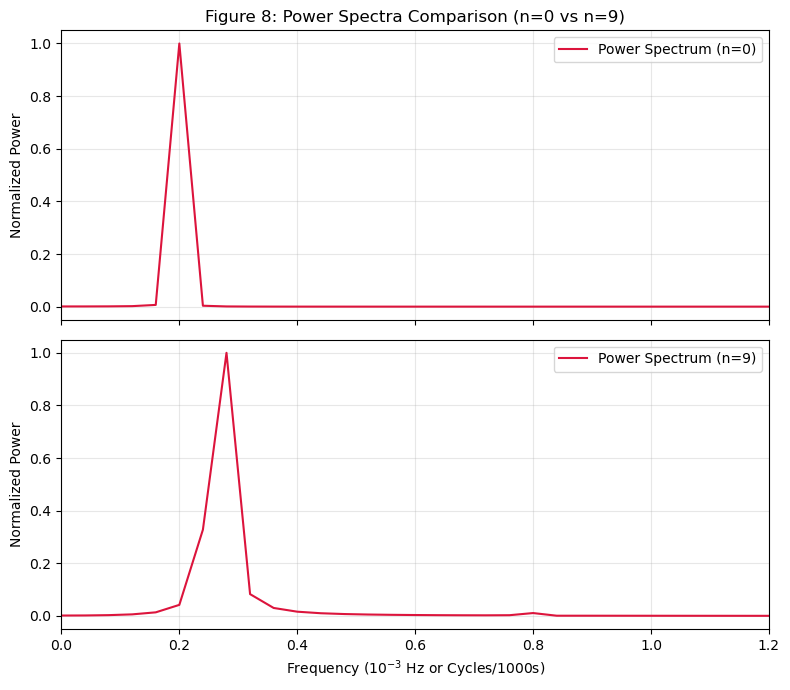

In [17]:
t_end_fft = 25000       # Increased time to capture multiple full cycles
dt = 2.0                 # Constant 2-second time step for uniform sampling
tt_fft = np.arange(0, t_end_fft, dt)

# Plot 
fig8, (ax_0, ax_9) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Run simulations and compute FFTs for n=0 and n=9

for n, ax in zip([0, 9], [ax_0, ax_9]):
    
    # Use pre-configured interpolators and state vectors
    
    sol_fft = solve_ivp(dydt_nonuniform, [0, t_end_fft], s0,
                        args=(n,), dense_output=True, max_step=10)
    
    # Extract uniform position array
    yy_n, _ = sol_fft.sol(tt_fft)
    
    # Calculate rfft
    fft_vals = np.fft.rfft(yy_n)
    
    #  Generate the matching frequency axis (1 / period)
    freqs = np.fft.rfftfreq(len(tt_fft), d=dt)
    
    # Calculate Power (Magnitude squared)
    power = np.abs(fft_vals)**2
    
    # Normalize power so maximum peak equals 1.0
    normalized_power = power / np.max(power)
    
    # Plotting, focusing on low frequencies where the peaks are
    
    ax.plot(freqs * 1000, normalized_power, color='crimson', lw=1.5, label=f'Power Spectrum (n={n})')
    ax.set_xlim(0, 1.2)  # Limit x-axis to highlight the dominant low-frequency spikes
    ax.set_ylabel('Normalized Power')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# Labeling Figure 8
ax_9.set_xlabel('Frequency ($10^{-3}$ Hz or Cycles/1000s)')
ax_0.set_title('Figure 8: Power Spectra Comparison (n=0 vs n=9)')
plt.tight_layout()
plt.show()


Describe what we see here:

For $n=0$: 

A single, isolated, sharp spike at a low frequency boundary $(f_0 \approx 1.97 \times 10^{-4}\text{ Hz})$. The rest of the spectrum is perfectly flat at zero.Physical Meaning: A uniform planet creates a perfect linear force trap (\(g \propto r\)). This produces Simple Harmonic Motion (SHM). The object oscillates as a pure, single-frequency cosine wave, which registers as a single spectral line in the frequency domain.

For $n=9$: 

The primary peak shifts to the right (higher frequency, shorter period). Additionally, a sequence of smaller secondary peaks appears at higher frequency intervals. Packing mass into the core makes the gravitational potential non-linear. The trajectory deforms into a sharp, non-sinusoidal "slingshot" path